In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

import time
import numpy as np


torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True

print(device)

cuda


In [2]:
#adjustable parameters
from AutoEncoder import Encoder
from OCT3D_DataLoader import load_oct_loader, N_DEMOGRAPHICS
from OCT3D_Pretrained_Classifier import PretrainedClassifier

num_epochs   = 15
classifier_lr= 1e-3 
encoder_lr   = 1e-6 
batch_size   = 2
num_classes  = 2    
latent_dim   = 8192
weight_decay = 1e-4 #to reduce overfitting

criterion = nn.CrossEntropyLoss()

weights = torch.load("models\\3d_oct_encoderSSIM.pth", map_location=device)
encoder = Encoder(latent_dim=latent_dim)
encoder.load_state_dict(weights)
encoder = encoder.to(device)

pretrained_classifier = PretrainedClassifier(latent_dim, num_classes, N_DEMOGRAPHICS).to(device)

#encoder overfits immediately so it must be frozen
for p in encoder.parameters():
    p.requires_grad = False
encoder.eval()

pretrained_optimizer = optim.Adam(pretrained_classifier.parameters(), lr=1e-3, weight_decay=weight_decay)


# pretrained_optimizer = optim.Adam([
#     {"params": encoder.parameters(), 'lr': encoder_lr},
#     {'params': pretrained_classifier.parameters(), 'lr': classifier_lr}
# ], weight_decay=weight_decay)

In [3]:

train_loader = load_oct_loader("Training", batch_size, shuffle=True)
val_loader = load_oct_loader("Validation", batch_size, shuffle=False)
test_loader = load_oct_loader("Test", batch_size, shuffle=False)

In [4]:
#training pretrained - classifier: 2 linear layers
start_time = time.perf_counter()

pretrained_train_losses = []
pretrained_val_losses = []

for epoch in range(num_epochs):
    encoder.train()
    pretrained_classifier.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels, demo in train_loader:
        images, labels, demo = images.to(device).float().div_(127.5).sub_(1.0), labels.to(device), demo.to(device)

        encoded = encoder(images)
        output = pretrained_classifier(encoded, demo)
        loss = criterion(output, labels)

        pretrained_optimizer.zero_grad()
        loss.backward()
        pretrained_optimizer.step()

        total_loss += loss.item()

        predicted = output.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    end_time = time.perf_counter()
    pretrained_train_losses.append(epoch_train_loss)
    

    #val
    pretrained_classifier.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels, demo in val_loader:
            images, labels, demo = images.to(device).float().div_(127.5).sub_(1.0), labels.to(device), demo.to(device)
            
            encoded = encoder(images)
            output = pretrained_classifier(encoded, demo)
            loss = criterion(output, labels)
            
            val_loss += loss.item()

            predicted = output.argmax(dim=1)

            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_accuracy = 100 * val_correct / val_total
    pretrained_val_losses.append(epoch_val_loss)

    print(
        f"Epoch {epoch+1}: "
        f"Training: Loss={epoch_train_loss:.4f}, "
        f"Accuracy={accuracy:.2f}%      "
        f"Validation: Loss={epoch_val_loss:.4f}, "
        f"Val Acc={epoch_val_accuracy:.2f}%"
    )
    


pretrained_accuracy = epoch_val_accuracy
pretrained_train_time = end_time - start_time

print(
    f"Results: Accuracy={pretrained_accuracy:.2f}% "
    f"Training Duration={pretrained_train_time:.6f} sec"
)

Epoch 1: Training: Loss=1.7753, Accuracy=60.95%      Validation: Loss=0.6020, Val Acc=70.33%
Epoch 2: Training: Loss=0.6843, Accuracy=62.48%      Validation: Loss=0.5994, Val Acc=69.33%
Epoch 3: Training: Loss=0.6826, Accuracy=62.71%      Validation: Loss=0.6410, Val Acc=63.33%
Epoch 4: Training: Loss=0.6792, Accuracy=59.67%      Validation: Loss=0.6120, Val Acc=65.33%
Epoch 5: Training: Loss=0.7244, Accuracy=59.90%      Validation: Loss=0.5952, Val Acc=69.00%
Epoch 6: Training: Loss=0.7159, Accuracy=59.57%      Validation: Loss=0.5986, Val Acc=65.33%
Epoch 7: Training: Loss=0.7537, Accuracy=57.05%      Validation: Loss=0.6091, Val Acc=61.33%
Epoch 8: Training: Loss=0.7201, Accuracy=56.86%      Validation: Loss=0.7546, Val Acc=55.00%
Epoch 9: Training: Loss=0.7627, Accuracy=55.62%      Validation: Loss=0.7009, Val Acc=57.00%
Epoch 10: Training: Loss=0.7573, Accuracy=56.43%      Validation: Loss=0.6560, Val Acc=55.67%
Epoch 11: Training: Loss=0.7061, Accuracy=55.19%      Validation: Los

In [18]:
#torch.save(encoder.state_dict(), "models/encoder.pth")
torch.save(pretrained_classifier.state_dict(), "models/frozen3d_classifier.pth")

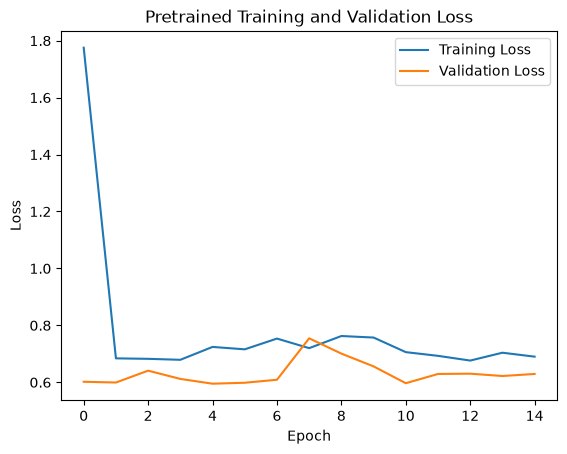

: 

In [ ]:
plt.plot(pretrained_train_losses, label="Training Loss")
plt.plot(pretrained_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Pretrained Training and Validation Loss")
plt.legend()
plt.show()

In [19]:
#test - pretrained

# test_encoder = Encoder(latent_dim=latent_dim).to(device)
# test_encoder.load_state_dict(torch.load("models/frozen3d_classifier.pth", map_location=device))
# test_encoder.eval()
encoder.eval()
#test_pretrained_classifier = PretrainedClassifier(latent_dim, num_classes, N_DEMOGRAPHICS).to(device)
#test_pretrained_classifier.load_state_dict(torch.load("models/frozen3d_classifier.pth", map_location=device))
test_pretrained_classifier = pretrained_classifier
test_pretrained_classifier.eval()
class_names = ["no glaucoma", "glaucoma"]

correct = 0
total = 0
conf_right, conf_wrong = 0.0, 0.0
n_wrong = 0
class_correct = {c: 0 for c in range(num_classes)}
class_total = {c: 0 for c in range(num_classes)}
tp = tn = fp = fn = 0

with torch.no_grad():
    for images, labels, demo in test_loader:
        images, labels, demo = images.to(device).float().div_(127.5).sub_(1.0), labels.to(device), demo.to(device)

        logits = pretrained_classifier(encoder(images), demo)
        probs = torch.softmax(logits, dim=1)
        predict = probs.argmax(dim=1)

        #true +/- false +/-
        tp += ((predict == 1) & (labels == 1)).sum().item()
        tn += ((predict == 0) & (labels == 0)).sum().item()
        fp += ((predict == 1) & (labels == 0)).sum().item()
        fn += ((predict == 0) & (labels == 1)).sum().item()

        #margin: how far ahead the winner is
        conf = probs.topk(2, dim=1).values.diff(dim=1).abs().squeeze(1)

        hit = (predict == labels)
        correct += hit.sum().item()
        total += labels.size(0)

        conf_right += conf[hit].sum().item()
        conf_wrong += conf[~hit].sum().item()
        n_wrong += (~hit).sum().item()

        for label, pred in zip(labels, predict):
            l = label.item()
            class_total[l] += 1
            class_correct[l] += int(l == pred.item())

print(f"Test accuracy:          {100 * correct / total:.2f}%")
print(f"Guessing baseline:      {100 * max(class_total.values()) / total:.2f}%")
print(f"Confidence when right:  {100 * conf_right / correct:.2f}%")
print(f"Confidence when wrong:  {100 * conf_wrong / n_wrong:.2f}%")
print()
print(f"{class_names[0]:<14} {100 * class_correct[0] / class_total[0]:>6.2f}%   specificity")
print(f"{class_names[1]:<14} {100 * class_correct[1] / class_total[1]:>6.2f}%   sensitivity")
print()
print(f"{'':<12}{'pred no':>10}{'pred yes':>10}")
print(f"{'actual no':<12}{100*tn/(tn+fp):>9.2f}%{100*fp/(tn+fp):>9.2f}%")
print(f"{'actual yes':<12}{100*fn/(fn+tp):>9.2f}%{100*tp/(fn+tp):>9.2f}%")
print()
print(f"False negatives (missed glaucoma): {100*fn/(fn+tp):.2f}%")
print(f"False positives (false alarms):    {100*fp/(tn+fp):.2f}%")

Test accuracy:          71.00%
Guessing baseline:      54.33%
Confidence when right:  47.77%
Confidence when wrong:  27.65%

no glaucoma     75.91%   specificity
glaucoma        66.87%   sensitivity

               pred no  pred yes
actual no       75.91%    24.09%
actual yes      33.13%    66.87%

False negatives (missed glaucoma): 33.13%
False positives (false alarms):    24.09%


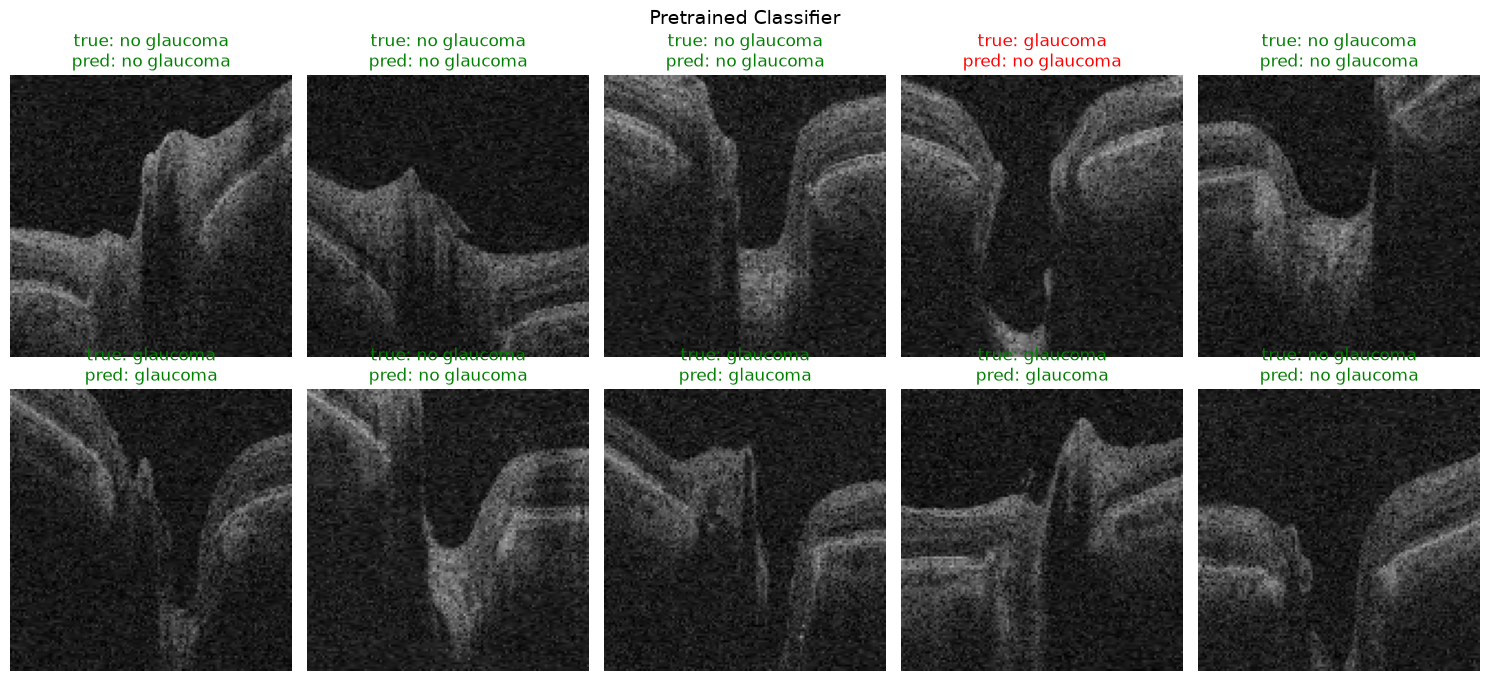

In [21]:
#visualizing results
class_names = ["no glaucoma", "glaucoma"]
N_SHOW = 10

imgs, demos, labs = [], [], []
for images, labels, demo in test_loader:
    imgs.append(images); demos.append(demo); labs.append(labels)
    if sum(len(x) for x in imgs) >= N_SHOW:
        break

imgs = torch.cat(imgs)[:N_SHOW]
demos = torch.cat(demos)[:N_SHOW]
labs = torch.cat(labs)[:N_SHOW]

encoder.eval()
test_pretrained_classifier.eval()
with torch.no_grad():
    x = imgs.to(device).float().div_(127.5).sub_(1.0)
    preds = test_pretrained_classifier(encoder(x), demos.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle("Pretrained Classifier", fontsize=14)

for ax, img, t, p in zip(axes.flat, imgs, labs.tolist(), preds.tolist()):
    ax.imshow(img[0, 64], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"true: {class_names[t]}\npred: {class_names[p]}",
                 color='green' if t == p else 'red')
    ax.axis('off')

plt.tight_layout()
plt.show()